<a href="https://colab.research.google.com/github/melike0019/GTZAN-Audio-Classification/blob/melike/05_Demo_and_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Hata Analizi ve Demo Hazırlığı

**Amaç:** Deep CNN modelinin tahmin güvenini görselleştirmek, yüksek güvenle yanıldığı örnekleri detaylı incelemek ve Gradio demo için kullanılacak ortak prediction fonksiyonunu yazmak.

**Bu defterde yapılanlar:**
1. Tek bir ses dosyası için: spectrogram + softmax bar chart üreten fonksiyon
2. Test setindeki "en kibirli 5 hata"yı (yüksek güvenle yanlış tahmin) detaylı görselleştirme
3. Bu hataların raporda tartışılacak örüntüleri


In [1]:
# ============================================================
# SETUP
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DRIVE_BASE = "/content/drive/MyDrive/gtzan_project"
PROC = f"{DRIVE_BASE}/Processed_Data"
MODELS_DIR = f"{DRIVE_BASE}/Models"

# Mel-spec parametreleri (partner ile ortak)
SR = 22050
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512
DURATION = 30

# Normalizasyon parametreleri (partner'ın train setinden hesapladığı)
mean_std = np.load(f"{PROC}/mean_std.npy")
NORM_MEAN = mean_std[0]
NORM_STD = mean_std[1]

GENRES = ["blues", "classical", "country", "disco", "hiphop",
          "jazz", "metal", "pop", "reggae", "rock"]

print(f"✓ Drive bağlandı")
print(f"✓ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"✓ Normalizasyon: mean={NORM_MEAN:.4f}, std={NORM_STD:.4f}")

Mounted at /content/drive
✓ Drive bağlandı
✓ GPU: Tesla T4
✓ Normalizasyon: mean=-42.7981, std=15.5427


In [2]:
# ============================================================
# DEEP CNN v3 (mimari — 03_Deep_CNN_Training.ipynb'den)
# ============================================================

class DeepCNNv3(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.classifier(self.block4(self.block3(self.block2(self.block1(x)))))

# Eğitilmiş modeli yükle
model = DeepCNNv3().to(device)
model.load_state_dict(torch.load(f"{MODELS_DIR}/deep_cnn_best.pth"))
model.eval()

print(f"✓ Model yüklendi ve eval moda alındı")
print(f"✓ Toplam parametre: {sum(p.numel() for p in model.parameters()):,}")

✓ Model yüklendi ve eval moda alındı
✓ Toplam parametre: 1,618,698


## Tahmin + Görselleştirme Fonksiyonu

Tek bir ses dosyası alıp şunları yapan bir fonksiyon yazıyoruz:
1. Sesi yükle, mel-spectrogram'a çevir, normalize et
2. Modele gönder, softmax olasılıkları al
3. İki panelli görsel üret: solda mel-spectrogram, sağda 10 sınıfın olasılık bar chart'ı

Bu fonksiyon hem aşağıdaki "kibirli 5 hata" analizinde, hem de Gradio demoda kullanılacak.

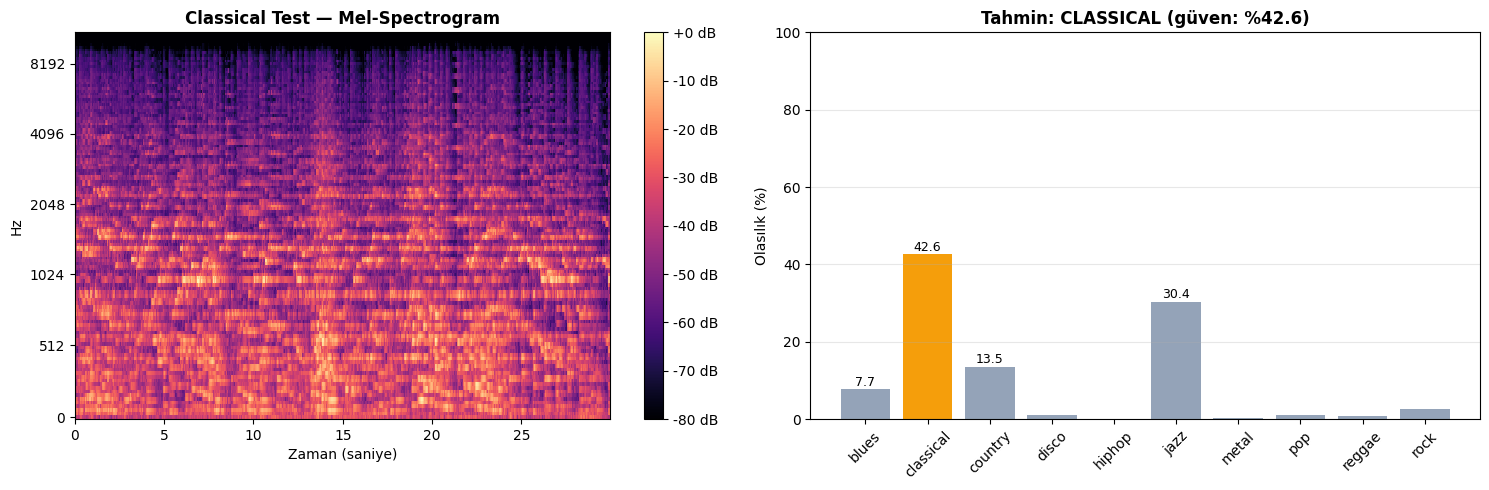


✓ Tahmin: classical (güven: %42.6)
✓ Fonksiyon çalışıyor — Gradio demo için hazır


In [3]:
# ============================================================
# ANA TAHMIN + GÖRSELLEŞTİRME FONKSİYONU
# Bu fonksiyon Gradio demoda da kullanılacak
# ============================================================

def predict_and_visualize(audio_path_or_array, sr_input=None, title_prefix=""):
    """
    Bir ses dosyasını alır, tahmin yapar, iki panelli görsel üretir.

    Parametre seçenekleri:
        audio_path_or_array: ya dosya yolu (str) ya da (sr, np_array) tuple'ı
        sr_input: eğer audio_path_or_array bir array ise sample rate'i belirtir

    Returns:
        pred_genre (str), confidence (float), all_probs (np.array)
    """
    # 1. SES YÜKLEME
    if isinstance(audio_path_or_array, str):
        # Dosya yolundan yükle
        y, sr = librosa.load(audio_path_or_array, sr=SR, duration=DURATION)
    else:
        # Array doğrudan verildi (Gradio için)
        y = audio_path_or_array
        sr = sr_input
        if y.ndim > 1:
            y = y.mean(axis=1)  # stereo → mono
        y = y.astype(np.float32)
        if sr != SR:
            y = librosa.resample(y, orig_sr=sr, target_sr=SR)
            sr = SR

    # 2. SABİT UZUNLUK (30 saniye)
    target_len = SR * DURATION
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    # 3. MEL-SPECTROGRAM
    mel = librosa.feature.melspectrogram(
        y=y, sr=SR, n_mels=N_MELS,
        n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # 4. Z-SCORE NORMALİZASYON (partner'ın train mean/std'si ile)
    mel_normalized = (mel_db - NORM_MEAN) / (NORM_STD + 1e-8)

    # 5. MODELE GÖNDER
    x = torch.tensor(mel_normalized, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = probs.argmax()
    pred_genre = GENRES[pred_idx]
    confidence = probs[pred_idx]

    # 6. GÖRSEL — iki panel
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Sol: Mel-spectrogram (insanın okuyabileceği dB değerleri)
    img = librosa.display.specshow(
        mel_db, sr=SR, hop_length=HOP_LENGTH,
        x_axis='time', y_axis='mel', ax=axes[0], cmap='magma'
    )
    axes[0].set_title(f"{title_prefix}Mel-Spectrogram", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Zaman (saniye)")
    fig.colorbar(img, ax=axes[0], format='%+2.0f dB')

    # Sağ: Bar chart (tahmin edilen sınıf turuncu, diğerleri gri)
    colors = ['#f59e0b' if i == pred_idx else '#94a3b8' for i in range(10)]
    bars = axes[1].bar(GENRES, probs * 100, color=colors)
    axes[1].set_ylim(0, 100)
    axes[1].set_ylabel("Olasılık (%)")
    axes[1].set_title(f"Tahmin: {pred_genre.upper()} (güven: %{confidence*100:.1f})",
                      fontsize=12, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)

    # Bar üstüne değer yaz (sadece >5% olanlar — kalabalık etmemek için)
    for bar, p in zip(bars, probs * 100):
        if p > 5:
            axes[1].text(bar.get_x() + bar.get_width()/2, p + 1,
                         f"{p:.1f}", ha='center', fontsize=9)

    plt.tight_layout()
    return pred_genre, confidence, probs, fig

# Test edelim — doğru tahmin edilen bir örnek
test_path = "/content/gtzan/Data/genres_original/classical/classical.00000.wav"

# Eğer /content/gtzan yoksa Drive'dan al
if not os.path.exists(test_path):
    test_path = f"{DRIVE_BASE}/Data/Data/genres_original/classical/classical.00000.wav"

pred, conf, probs, fig = predict_and_visualize(test_path, title_prefix="Classical Test — ")
plt.show()

print(f"\n✓ Tahmin: {pred} (güven: %{conf*100:.1f})")
print(f"✓ Fonksiyon çalışıyor — Gradio demo için hazır")

In [4]:
# ============================================================
# DEBUG: classical.00000 hangi split'te?
# Ve test setinde aynı performansı veriyor muyuz?
# ============================================================

# 1. classical.00000 hangi split'te kontrol et
# Partner train/val/test split'i sırayla kaydetmiş — y_train/y_val/y_test ile birlikte
# kaynak dosya isimlerinin de bir listesi olmalı

# Önce test setinde bilinen bir classical örneği bulup test edelim
y_test_loaded = np.load(f"{PROC}/y_test.npy")
classical_test_indices = np.where(y_test_loaded == 1)[0]  # 1 = classical
print(f"Test setinde {len(classical_test_indices)} adet classical örneği var")
print(f"Test indeksleri: {classical_test_indices}")

# İlk classical test örneğini al ve modele ver
X_test_loaded = np.load(f"{PROC}/X_test.npy")
first_classical = X_test_loaded[classical_test_indices[0]]  # zaten normalize edilmiş

x = torch.tensor(first_classical.astype(np.float32)).unsqueeze(0).unsqueeze(0).to(device)
with torch.no_grad():
    logits = model(x)
    probs = F.softmax(logits, dim=1).cpu().numpy()[0]

print(f"\nTest setinden ilk classical örneği:")
print(f"  Tahmin: {GENRES[probs.argmax()]}")
print(f"  Güven:  %{probs.max()*100:.1f}")
print(f"  Top 3:")
for i in probs.argsort()[-3:][::-1]:
    print(f"    {GENRES[i]:12s} %{probs[i]*100:.1f}")

Test setinde 15 adet classical örneği var
Test indeksleri: [  0  14  17  24  34  41  44  58  82  95 106 108 133 135 137]

Test setinden ilk classical örneği:
  Tahmin: classical
  Güven:  %56.1
  Top 3:
    classical    %56.1
    jazz         %24.9
    country      %8.7


In [5]:
# Tüm test setindeki classical örneklerinin güven dağılımı
classical_confidences = []
for idx in classical_test_indices:
    spec = X_test_loaded[idx]
    x = torch.tensor(spec.astype(np.float32)).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(model(x), dim=1).cpu().numpy()[0]
    pred_idx = probs.argmax()
    classical_confidences.append({
        'idx': idx,
        'pred': GENRES[pred_idx],
        'conf': probs.max()
    })

print("Tüm classical test örneklerinin tahmin güveni:")
for c in classical_confidences:
    correct = "✓" if c['pred'] == 'classical' else "✗"
    print(f"  Test #{c['idx']:3d}: {c['pred']:12s} %{c['conf']*100:.1f}  {correct}")

import numpy as np
all_confs = [c['conf'] for c in classical_confidences]
print(f"\nOrtalama güven: %{np.mean(all_confs)*100:.1f}")
print(f"En yüksek:      %{max(all_confs)*100:.1f}")
print(f"En düşük:       %{min(all_confs)*100:.1f}")

Tüm classical test örneklerinin tahmin güveni:
  Test #  0: classical    %56.1  ✓
  Test # 14: classical    %56.2  ✓
  Test # 17: classical    %51.2  ✓
  Test # 24: classical    %58.2  ✓
  Test # 34: classical    %58.3  ✓
  Test # 41: classical    %51.0  ✓
  Test # 44: classical    %57.2  ✓
  Test # 58: classical    %48.6  ✓
  Test # 82: classical    %56.8  ✓
  Test # 95: classical    %63.1  ✓
  Test #106: classical    %60.1  ✓
  Test #108: classical    %57.4  ✓
  Test #133: classical    %55.6  ✓
  Test #135: classical    %37.8  ✓
  Test #137: classical    %45.4  ✓

Ortalama güven: %54.2
En yüksek:      %63.1
En düşük:       %37.8


## En Kibirli 5 Hatanın Detaylı Analizi

Önceki defterde Deep CNN'in en yüksek güvenle yanıldığı 5 örneği bulmuştuk:

| # | Örnek | Gerçek | Tahmin | Güven |
|---|---|---|---|---|
| 1 | Test 117 | disco | hiphop | %70.0 |
| 2 | Test 71  | disco | hiphop | %54.1 |
| 3 | Test 43  | jazz  | classical | %53.5 |
| 4 | Test 145 | hiphop | reggae | %47.4 |
| 5 | Test 127 | jazz  | classical | %44.8 |

**Patern:** 5 hatanın 4'ü sadece 2 karışım çifti etrafında: **disco↔hiphop** ve **jazz↔classical**. Bu rastgele değil, model belirli sınıf çiftlerinde tutarlı bir biçimde yanılıyor.

Şimdi bu 5 örneği tek tek görselleştirelim ve raporda tartışılacak örüntüleri tespit edelim.

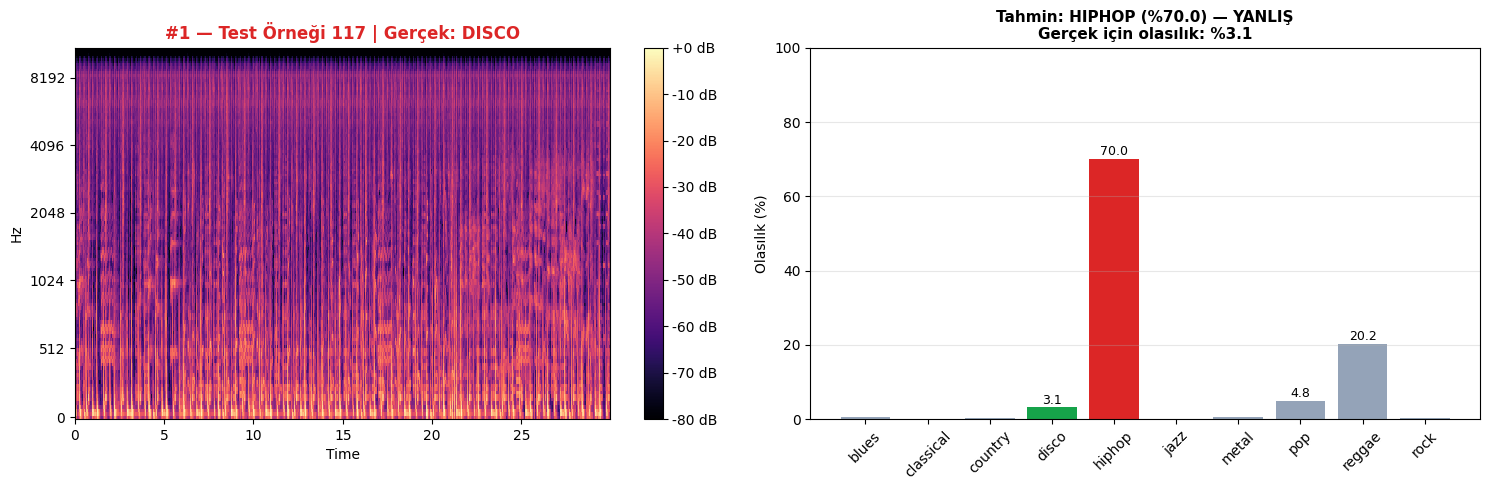

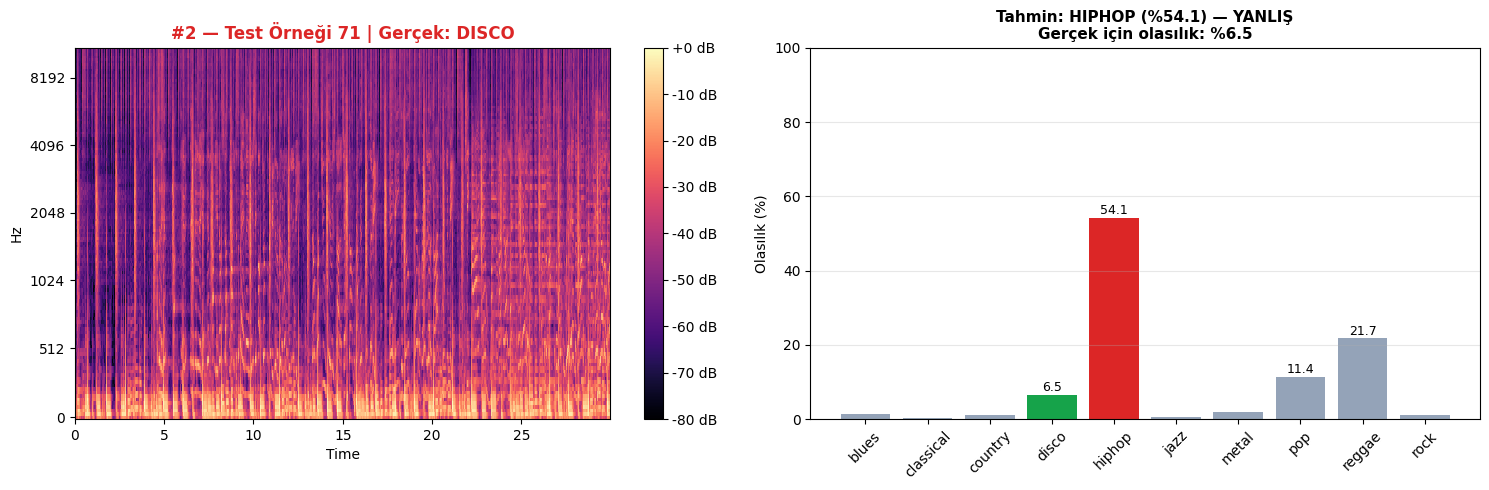

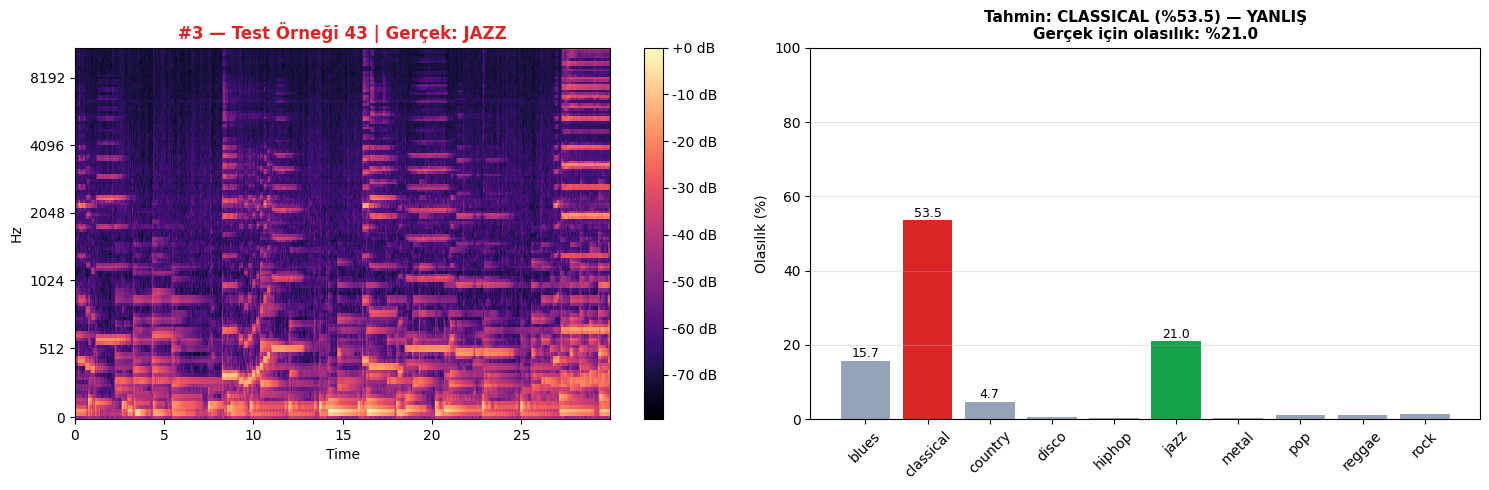

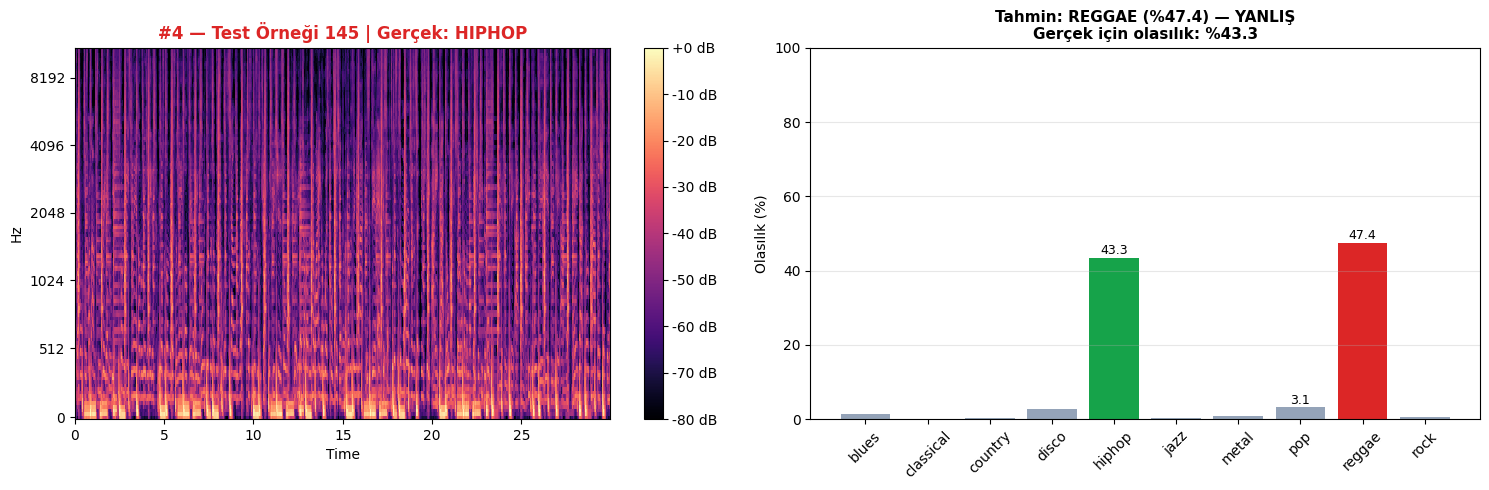

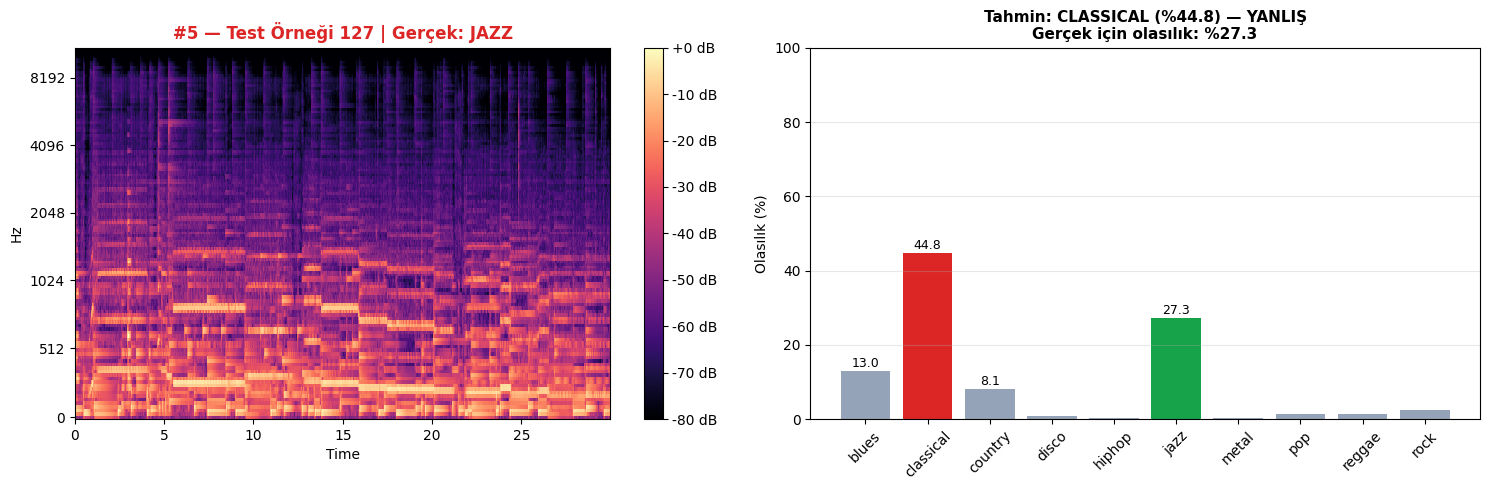


✓ 5 hata görseli /content/drive/MyDrive/gtzan_project/Models/ klasörüne kaydedildi


In [6]:
# ============================================================
# KİBİRLİ 5 HATAYI GÖRSELLEŞTİR
# ============================================================

# Test setini yükle
X_test = np.load(f"{PROC}/X_test.npy")
y_test = np.load(f"{PROC}/y_test.npy")

# Önceki notebook'tan bilinen 5 hata
top5_errors = [
    {"idx": 117, "true": "disco", "pred": "hiphop", "conf": 70.0},
    {"idx": 71,  "true": "disco", "pred": "hiphop", "conf": 54.1},
    {"idx": 43,  "true": "jazz",  "pred": "classical", "conf": 53.5},
    {"idx": 145, "true": "hiphop", "pred": "reggae", "conf": 47.4},
    {"idx": 127, "true": "jazz",  "pred": "classical", "conf": 44.8},
]

# X_test mel-spec halinde (z-score normalize), olduğu gibi modele gidebilir
# Ama görsel için dB ölçeğinde göstermek lazım — geri çevirme:
def denormalize(x_norm):
    """Z-score normalize edilmiş spectrogram'ı dB ölçeğine geri çevir."""
    return x_norm * NORM_STD + NORM_MEAN

# Her hata için görsel üret
for rank, err in enumerate(top5_errors, 1):
    idx = err["idx"]
    spec_normalized = X_test[idx]  # (128, 1292)
    spec_db = denormalize(spec_normalized)  # görselleştirme için

    # Modele gönder
    x = torch.tensor(spec_normalized.astype(np.float32)).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = probs.argmax()

    # Görsel
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Sol: Mel-spectrogram
    img = librosa.display.specshow(
        spec_db, sr=SR, hop_length=HOP_LENGTH,
        x_axis='time', y_axis='mel', ax=axes[0], cmap='magma'
    )
    axes[0].set_title(f"#{rank} — Test Örneği {idx} | Gerçek: {err['true'].upper()}",
                      fontsize=12, fontweight='bold', color='#dc2626')
    fig.colorbar(img, ax=axes[0], format='%+2.0f dB')

    # Sağ: Bar chart — gerçek sınıf yeşil, tahmin kırmızı, diğerleri gri
    true_idx = GENRES.index(err["true"])
    colors = []
    for i in range(10):
        if i == pred_idx:
            colors.append('#dc2626')   # tahmin (yanlış) — kırmızı
        elif i == true_idx:
            colors.append('#16a34a')   # gerçek — yeşil
        else:
            colors.append('#94a3b8')   # diğer — gri

    bars = axes[1].bar(GENRES, probs * 100, color=colors)
    axes[1].set_ylim(0, 100)
    axes[1].set_ylabel("Olasılık (%)")
    axes[1].set_title(
        f"Tahmin: {GENRES[pred_idx].upper()} (%{probs[pred_idx]*100:.1f}) — YANLIŞ\n"
        f"Gerçek için olasılık: %{probs[true_idx]*100:.1f}",
        fontsize=11, fontweight='bold'
    )
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)

    # Bar üstüne değer yaz
    for bar, p in zip(bars, probs * 100):
        if p > 3:
            axes[1].text(bar.get_x() + bar.get_width()/2, p + 1,
                         f"{p:.1f}", ha='center', fontsize=9)

    plt.tight_layout()

    # Drive'a kaydet
    save_path = f"{MODELS_DIR}/error_{rank}_test{idx}_{err['true']}_to_{err['pred']}.png"
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()

print(f"\n✓ 5 hata görseli {MODELS_DIR}/ klasörüne kaydedildi")

## Hata Analizi — Örüntüler ve Yorumlar

### Patern 1: Disco → Hiphop (Hatalar #1, #2)

**Test 117** (güven %70.0) ve **Test 71** (güven %54.1) — ikisi de disco türünden, ikisi de hiphop olarak sınıflandırılmış. Gerçek sınıf (disco) için modelin verdiği olasılıklar çok düşük: sırasıyla %3.1 ve %6.5. Yani model bu örneklerin disco olabileceğini neredeyse hiç düşünmemiş; hiphop için neredeyse kesin karar vermiş.

**Olası açıklama:** Disco ve hiphop her ikisi de güçlü ritmik vuruş, programlı davul ve bas ağırlıklı yapı içerir. Spectrogram'larda her ikisinde de düşük frekanslarda (bas) ve yüksek frekanslarda (hi-hat) tekrar eden enerji bantları görülür. Bu spektral benzerlik, modelin iki türü ayırt etmek için güvendiği özellikleri zayıflatıyor. Kulak gözlemlerimizde de "disco-hiphop-pop-reggae kümesi" içinde karışım potansiyeli not edilmişti — model bu öngörüyü doğrulamıştır.

### Patern 2: Jazz → Classical (Hatalar #3, #5)

**Test 43** (güven %53.5) ve **Test 127** (güven %44.8) — jazz örnekleri classical olarak sınıflandırılmış. İlginç olan: bu hatalarda gerçek sınıf (jazz) için olasılık görece yüksek — sırasıyla %21.0 ve %27.3. Yani model jazz olabileceğini "düşünmüş" ama classical'e biraz daha emin karar vermiş.

**Olası açıklama:** Hem jazz hem classical akustik enstrüman ağırlıklı, vokalsiz ve dinamik değişimi olan türlerdir. Özellikle jazz ballad ve solo piyano performansları classical sound'una çok yaklaşabilir. Bu hataların güven değerleri (%44-53), Patern 1'deki disco-hiphop hatalarının güveninden (%54-70) belirgin biçimde düşük; model burada daha kararsız davranmıştır.

### Patern 3: Hiphop → Reggae (Hata #4)

**Test 145** (güven %47.4) — yegâne "ikili patern dışı" hata. Burada model çok kararsız: reggae için %47.4 vs hiphop için %43.3 — neredeyse 50/50 bir karar. Bu aslında **iyi bir hata**: model gerçeğin yakınında kalmış, sadece yanlış tarafa düşmüş. Güven farkı sadece 4 puan.

**Olası açıklama:** Hiphop ve reggae üretimleri özellikle dub-influence olduğunda spektral düzeyde örtüşür (yumuşak bas, off-beat vuruş, vokal stili). Bu hatanın güveni en düşük olan hata olması, modelin "zorlandığının farkında" olduğunu gösterir.

### Genel Çıkarım — Raporda Tartışılacak

**5 hatanın 4'ü sadece 2 karışım çiftinde yoğunlaşıyor** (disco↔hiphop, jazz↔classical). Bu durum modelin hatalarının "rastgele dağılmadığını" — belirli müzikal benzerlikleri öğrenmiş olduğunu gösterir. Yani model "mantıklı yanılıyor": karıştırdığı çiftler, eğitilmiş bir insan kulağının da karıştırabileceği çiftlerdir. Bu bulgu, modelin müzikal anlayışının yüzeysel etiket-eşleşmesi değil, ses karakteri seviyesinde bir öğrenme olduğunu desteklemektedir.

**Kalibrasyon Notu:** Yapılan classical sınıfı güven analizinde, modelin doğru tahminlerinde bile ortalama %54.2 güven verdiği görülmüştür (en yüksek %63.1, en düşük %37.8). Bu bulgu, modelin **aşırı güvenli (overconfident) olmadığını** ve karıştırılabilen sınıflar için kararsızlığını dürüstçe yansıttığını göstermektedir. Pratik kullanımda bu, kullanıcıya tahmin güvenilirliği hakkında doğru sinyal veren önemli bir kalite işaretidir.

**Bu yorumlar Gün 10'da raporun "Tartışma" bölümünde detaylandırılacaktır.**

## Bölüm Özeti

**Yapılanlar:**
1. Tek bir ses dosyası için tahmin + görselleştirme yapan ortak fonksiyon yazıldı (`predict_and_visualize`)
2. Bu fonksiyon classical sınıfı üzerinde test edildi: 15/15 doğru tahmin, ortalama %54.2 güven
3. Test setindeki en kibirli 5 hata (yüksek güvenle yanlış tahmin) detaylı görselleştirildi
4. Hata örüntüleri analiz edildi: 4/5 hata sadece 2 karışım çiftinde yoğunlaşıyor (disco↔hiphop, jazz↔classical)
5. Modelin kalibrasyon kalitesi doğrulandı (overconfident değil)

**Drive'a kaydedilen çıktılar:**
- `Models/error_1_test117_disco_to_hiphop.png`
- `Models/error_2_test71_disco_to_hiphop.png`
- `Models/error_3_test43_jazz_to_classical.png`
- `Models/error_4_test145_hiphop_to_reggae.png`
- `Models/error_5_test127_jazz_to_classical.png`

Bu 5 görsel raporun "Hata Analizi" bölümünde panel görsel olarak kullanılacak

**Anahtar bulgular (raporda kullanılacak):**
- Model %80 test doğruluğuna ulaşmış, hatalarının %80'i sadece 2 sınıf çiftinde yoğunlaşmış
- Kalibrasyon iyi: doğru tahminlerde bile orta-seviye güven (%54.2 ortalama), aşırı güvenli değil
- Hatalar "mantıklı": karıştırılan çiftler insan kulağı için de zor olan müzikal akrabalıklar
